![Plan of action](images/advance_chatbot_plan.png)


This is whole plan of an advance ChatBot which will have features like -
 - chatting
 - RAG
    - memore. persitence, Human in the loop (HIL), Retry
 - Tools calling
 - UI
 - LangSmith for logging

This notebook is a chatbot with persistence

### This notebook is an implementation of a simple chatbot with 

![workflow](images/chatbot1.png)

In [3]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START,END, add_messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage,HumanMessage



When we talk to an LLM we talk via messages. In the LangChain there a few types of messages. 

user: "What is the capital of India?" -> this is HumanMessage
AI: "New Delhi" -> AIMessage

SystemMessage : to specify a role to an LLM ( is defined by use)
ToolMessage : to define a definition for a tool called by an LLM

Above four types of messages inheret from BaseMessage. 

In [4]:
class ChatState(TypedDict):

    messages : Annotated[list[BaseMessage], add_messages]  # it contains any types of messages


In [5]:
llm = ChatOpenAI()

In [13]:
def chat_node(state: ChatState):

    message = state['messages']

    response = llm.invoke(message)

    return {'messages': [response]}

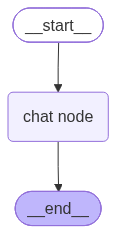

In [14]:
graph = StateGraph(ChatState)

graph.add_node("chat node", chat_node)

graph.add_edge(START, "chat node")
graph.add_edge("chat node", END)

chatbot = graph.compile()

chatbot

In [16]:
initial_state = {
    "messages": [HumanMessage(content="what is capital of India?")]
    }

responses = chatbot.invoke(initial_state)
responses

{'messages': [HumanMessage(content='what is capital of India?', additional_kwargs={}, response_metadata={}, id='b2bb4983-c8c4-42eb-81c9-3f3d8ad57ef4'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 13, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EAROXy3awSvCXfehRiyGAxfqahBBS', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fdf45-5d35-7150-8db7-73ae1937f3fe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 8, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_d

In [18]:
# building a loop for continuous chatting

while True:

    user_input = input("What to ask?")

    if user_input.strip().lower() in ['exit', 'quit', 'bye']:
        break

    initial_messages ={
        'messages': [HumanMessage(content=user_input)]
    }
    response = chatbot.invoke(initial_messages)

    print(f'AI: {response['messages'][-1].content}')


AI: I am a computer program designed to assist and interact with users to provide information and answer questions.
AI: The color of the sky is typically blue, but can also appear white, gray, orange, pink, or purple depending on the time of day and weather conditions.
